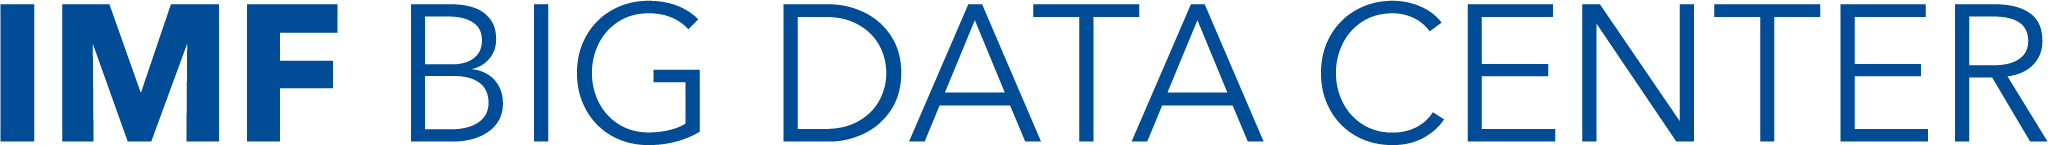

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AlessandraSozzi/STI_2026/blob/main/notebooks/BDC_Cropland_statistics_from_satellite_imageries.ipynb)

# Cropland statistics from satellite imageries


---

<br>**Contributors:** [Alessandra Sozzi](asozzi@imf.org) & [Mario Saraiva](msaraiva@imf.org)
<br> **Last update:** Oct-2025
<br> **Description:** This notebook showcase methods to derive cropland statistics from satellite imageries.
<br> **References:**

Useful links and references

- [Google Earth Engine](https://earthengine.google.com/)
- [Create a google / gmail account if you do not have one already](https://support.google.com/mail/answer/56256?hl=en)
- [Try to log-on to google colab account with you gmail account](https://colab.research.google.com/)
- [Sign up for an Earth Engine account](https://earthengine.google.com/signup/)
- [Geemap website](https://geemap.org/)
- [Geemap book](https://book.geemap.org/)
- [Geemap YouTube videos](https://youtube.com/@giswqs)
- [Learn more about Google Earth Engine, usage and applications](https://courses.spatialthoughts.com/end-to-end-gee.html)
- [Dynamic World](https://dynamicworld.app/)
- [Explore Dynamic World data exploration tool here](https://dynamicworld.app/explore)

## Setup

#### Mount the drive and adjust the path

In [1]:
# Mounth the drive to access file in the Google Drive folder
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [15]:
# Set the main path for the workshop files
import os

ROOT = "/content/drive/MyDrive/STI_2026"
workshop_path = os.path.join(ROOT, "Day 2 - Satellite Data Fundamentals/Cropland Statistics")
data_path = os.path.join(workshop_path, "data")

# Check if working
print("Worshop path found: ", os.path.exists(workshop_path))
print("Data path found: ", os.path.exists(data_path))

Worshop path found:  True
Data path found:  True


### Authenticate Google Earth Engine

In [2]:
import ee
ee.Authenticate()
my_project_name = 'ee-bigdatacenter-1' # USE YOUR OWN GOOGLE CLOUD PROJECT
ee.Initialize(project=my_project_name)

### Libraries

In [3]:
import geemap

import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt

## Country for this Excercise

In [4]:
country_name="Republic of Moldova"

## FAO Boundary Data: GAUL 2024

**Source:** [🌍 GEE Community Catalog – GAUL](https://gee-community-catalog.org/projects/gaul/)  

---

## 🧭 Overview  
The **Global Administrative Unit Layers (GAUL 2024)** dataset, produced by **FAO**, provides a globally consistent set of administrative boundary layers — from country (level 0) down to district (level 2).  

**Interactive Map:** [🗺️ Explore all Level 1 boundaries on the FAO Data App](https://data.apps.fao.org/catalog/dataset/34f97afc-6218-459a-971d-5af1162d318a/resource/d472b55c-a1e0-4c9c-9ccb-8bf10c8bf0a3)  


In [21]:
countries = ee.FeatureCollection("projects/sat-io/open-datasets/FAO/GAUL/GAUL_2024_L1")

In [24]:
countries.first()

In [19]:
# Load and filter the FeatureCollections for the selected country
country_l1 = ee.FeatureCollection("projects/sat-io/open-datasets/FAO/GAUL/GAUL_2024_L1") \
               .filter(ee.Filter.eq('iso3_code', 'MDA'))

In [6]:
# Take a pick at the first feature in the collection

country_l1.first()

In [7]:
country_l1

Output hidden; open in https://colab.research.google.com to view.

In [8]:
Map = geemap.Map()

# Add country boundary L1
Map.addLayer(country_l1.style(**{'fillColor': '00000000', 'color': 'blue', 'width': 2}), {}, country_name)

# Center map on the country
Map.centerObject(country_l1, zoom=7)

Map

Map(center=[47.19462018092226, 28.473955181059008], controls=(WidgetControl(options=['position', 'transparent_…

# **Crop Areas Statistics**

In this section, we will derive crop-land statistics using three global land-cover datasets: **ESA WorldCover**, **Esri Land Cover**, and **Google Dynamic World**.  
These 10 m products differ in classification approach, temporal resolution, and accuracy, so comparing them helps assess consistency and uncertainty in cropland estimates.

A global comparison by **Venter et al. (2022)** evaluated these datasets and found that:
- All three show strong spatial agreement for major classes such as crops, water, and built-up areas.  
- **Esri Land Cover** achieved the highest overall accuracy (approx. 75%), followed by **Dynamic World** (approx. 72%) and **WorldCover** (approx. 65%).  
- Each dataset has distinct biases — for example, Esri tends to over-classify shrubland, WorldCover grassland, and Dynamic World snow/ice.  

> **Reference:**  
> Venter, Z. S., Barton, D. N., Chakraborty, T., Simensen, T., & Singh, G. (2022).  
> *Global 10 m Land Use Land Cover Datasets: A Comparison of Dynamic World, World Cover and Esri Land Cover.*  
> *Remote Sensing,* 14(16), 4101. [https://doi.org/10.3390/rs14164101](https://doi.org/10.3390/rs14164101)


## 🌾 **What defines crop areas in land cover maps?**

**Definition:**  
Areas where the **vegetation is planted, cultivated, and actively managed by humans for harvest**. This includes annual and perennial agricultural crops, as well as managed orchards and plantations with a clear spatial pattern or field structure.

**Includes:**  
- Annual and perennial croplands (e.g., cereals, vegetables, legumes)  
- Managed orchards, vineyards, and plantations  
- Fallow fields temporarily without vegetation but within agricultural parcels  

**Excludes:**  
- Natural grasslands or pastures (classified as **Grass**)  
- Forests or tree plantations dominated by natural growth (classified as **Trees**)  
- Flooded or paddy fields under water at observation time (may appear as **Flooded vegetation**)  

**Spectral characteristics:**  
Crop areas exhibit **high near-infrared (NIR)** and **low red reflectance** during the growing season, producing strong vegetation indices such as **NDVI**. Temporal variation across months is common due to crop cycles.

## ESA WordCover

The European Space Agency (ESA) WorldCover 10 m 2020 and 2021 product provides a global land cover map for 2020 and 2021 at 10 m resolution based on Sentinel-1 and Sentinel-2 data. The WorldCover product comes with 11 land cover classes and has been generated in the framework of the ESA WorldCover project, part of the 5th Earth Observation Envelope Programme (EOEP-5) of the European Space Agency.

- [ESA WorldCover website](https://esa-worldcover.org/)
- [EAS WroldCover in the Earth Engine Data Catalog](https://developers.google.com/earth-engine/datasets/catalog/ESA_WorldCover_v100)
- [User Manual and Validation Report](https://esa-worldcover.org/en/data-access)

### Accessing ESA Land Cover From GEE

In [9]:
Map = geemap.Map()

# Create a map centered on country
Map.add_basemap('HYBRID')

# Load the ESA WorldCover image
esa = ee.ImageCollection("ESA/WorldCover/v100").first()
esa_vis = {'bands': ['Map']}

# Load country boundary from FAO GAUL or large-scale dataset
country_l1 = ee.FeatureCollection("projects/sat-io/open-datasets/FAO/GAUL/GAUL_2024_L1") \
             .filter(ee.Filter.eq('gaul0_name', country_name))

# Clip the ESA image to country
esa_clipped = esa.clip(country_l1)

# Add the clipped layer to the map
Map.addLayer(esa_clipped, esa_vis, "ESA Land Cover" + country_name)

# Add country boundary L1
Map.addLayer(country_l1.style(**{'fillColor': '00000000', 'color': 'blue', 'width': 2}), {}, country_name,
             shown=False)

# Add legend
Map.add_legend(title="ESA LandCover on Earth Engine", builtin_legend='ESA_WorldCover')

# Center map on country
Map.centerObject(country_l1, zoom=7)

Map


Map(center=[47.19462018092226, 28.473955181059008], controls=(WidgetControl(options=['position', 'transparent_…

### Let us take look at crop land satatistics

In [11]:
Map = geemap.Map()

# Create a map centered on country
Map.add_basemap('HYBRID')

# Load ESA WorldCover
esa = ee.ImageCollection("ESA/WorldCover/v100").first()

# Load country boundary from FAO GAUL
country_l1 = ee.FeatureCollection("projects/sat-io/open-datasets/FAO/GAUL/GAUL_2024_L1") \
             .filter(ee.Filter.eq('gaul0_name', country_name))

# Keep cropland pixels only (class 40)
cropland = esa.eq(40).clipToCollection(country_l1).selfMask()

# Visualize cropland
Map.addLayer(cropland, {'palette': ['f096ff']}, 'Cropland')

# Optionally hide the original ESA Land Cover layer if added
Map.show_layer(name='ESA Land Cover', show=False)

# Center the map
Map.centerObject(country_l1, zoom=7)

Map


Map(center=[47.19462018092224, 28.473955181059015], controls=(WidgetControl(options=['position', 'transparent_…

### Generate zonal statistics

In [13]:
import os

In [16]:
# Export zonal stats of cropland area per region to CSV
geemap.zonal_stats(
    cropland,                     # Raster layer (cropland)
    country_l1,                   # Vector features (L1 regions)
    os.path.join(data_path, 'esa_cropland.csv'),           # Output filepath
    statistics_type='SUM',        # Sum of pixels
    scale=1000,                   # Spatial resolution
    denominator=1e6,              # Convert m² to km²
    verbose=True,
)


Computing statistics ...
Generating URL ...
Please wait ...
Data downloaded to /content/drive/MyDrive/STI_2026/Day 2 - Satellite Data Fundamentals/Cropland Statistics/data/esa_cropland.csv


### We use geemap function to convert it to a dataframe

In [17]:
import pandas as pd

# Load the CSV as a DataFrame
df_esa = geemap.csv_to_df(os.path.join(data_path, 'esa_cropland.csv'))

# View the first rows
df_esa.head()


,sum,gaul0_name,continent,iso3_code,disp_en,map_code,gaul1_code,gaul0_code,gaul1_name,system:index
0,805.450980,Republic of Moldova,Europe,MDA,"Anenii Noi, Republic of Moldova",MDA,3737,326,Anenii Noi,000100000000000001d3
1,50.984314,Republic of Moldova,Europe,MDA,"Balti, Republic of Moldova",MDA,3738,326,Balti,000100000000000001d4
2,288.694118,Republic of Moldova,Europe,MDA,"Basarabeasca, Republic of Moldova",MDA,3739,326,Basarabeasca,000100000000000001d5
3,20.796078,Republic of Moldova,Europe,MDA,"Bender, Republic of Moldova",MDA,3740,326,Bender,000100000000000001d6
4,901.941176,Republic of Moldova,Europe,MDA,"Briceni, Republic of Moldova",MDA,3741,326,Briceni,000100000000000001d7


### We can also plot in a bar chat to better vizualize the distribution and variability across the continent

In [18]:
# Bar chart of cropland area per region
geemap.bar_chart(
    df_esa, # cleanup regional names
    x='gaul1_name', y='sum',
    max_rows=50,
    x_label='',
    y_label='Cropland Area (km²)'
)


## ESRI 10m Annual Land Cover (2017-2024)


For extended time-series data, we have the ESRI Global Land Cover datasset

The Esri Global Land Cover v3 (2017–2024) dataset provides annual global 10 m resolution maps of land use and land cover derived from Sentinel-2 imagery. Each yearly map represents a composite snapshot of nine LULC classes. The product was developed by Impact Observatory using a deep-learning model trained on billions of human-labeled pixels curated by the National Geographic Society, and applied globally via Microsoft’s Planetary Computer platform.

References:
- https://geemap.org/
- https://livingatlas.arcgis.com/landcover/


> Karra, Kontgis, et al. “Global land use/land cover with Sentinel-2 and deep learning.”
IGARSS 2021-2021 IEEE International Geoscience and Remote Sensing Symposium. IEEE, 2021.

In [25]:
# we prepare the dataset

Map = geemap.Map()
Map.add_basemap('HYBRID')

# Load country regional boundaries
country_l1 = ee.FeatureCollection("projects/sat-io/open-datasets/FAO/GAUL/GAUL_2024_L1") \
             .filter(ee.Filter.eq('gaul0_name', country_name))


esri = ee.ImageCollection(
    'projects/sat-io/open-datasets/landcover/ESRI_Global-LULC_10m_TS'
)

# We create a yearly mosaics, ie we combines (or “stitches”) all filtered images
# into a single composite image. It takes the topmost non-masked pixel from
# each stack of overlapping images — often used for cloud-free mosaics or year composites.
esri_2017 = esri.filterDate('2017-01-01', '2017-12-31').mosaic().clip(country_l1)
esri_2018 = esri.filterDate('2018-01-01', '2018-12-31').mosaic().clip(country_l1)
esri_2019 = esri.filterDate('2019-01-01', '2019-12-31').mosaic().clip(country_l1)
esri_2020 = esri.filterDate('2020-01-01', '2020-12-31').mosaic().clip(country_l1)
esri_2021 = esri.filterDate('2021-01-01', '2021-12-31').mosaic().clip(country_l1)
esri_2022 = esri.filterDate('2022-01-01', '2022-12-31').mosaic().clip(country_l1)
esri_2023 = esri.filterDate('2023-01-01', '2023-12-31').mosaic().clip(country_l1)
esri_2024 = esri.filterDate('2024-01-01', '2024-12-31').mosaic().clip(country_l1)

esri_vis = {'min': 1, 'max': 11, 'palette': 'esri_lulc'}

Map.addLayer(esri_2017, esri_vis, 'ESRI LULC 2017')
Map.addLayer(esri_2018, esri_vis, 'ESRI LULC 2018')
Map.addLayer(esri_2019, esri_vis, 'ESRI LULC 2019')
Map.addLayer(esri_2020, esri_vis, 'ESRI LULC 2020')
Map.addLayer(esri_2021, esri_vis, 'ESRI LULC 2021')
Map.addLayer(esri_2022, esri_vis, 'ESRI LULC 2022')
Map.addLayer(esri_2023, esri_vis, 'ESRI LULC 2023')
Map.addLayer(esri_2024, esri_vis, 'ESRI LULC 2024')

# Add country boundary L1
Map.addLayer(country_l1.style(**{'fillColor': '00000000', 'color': 'blue', 'width': 2}), {}, country_name,
             shown=False)

# Add legend and center the map
Map.add_legend(title='ESRI Land Cover', builtin_legend='ESRI_LandCover_TS')
Map.centerObject(country_l1, zoom=7)
Map

Map(center=[47.19462018092226, 28.473955181059008], controls=(WidgetControl(options=['position', 'transparent_…

### With Timeseries Inspector, we can take a look at changes between two epochs side by side

In [27]:
# first we create image time list
images = ee.List([esri_2017, esri_2018, esri_2019, esri_2020, esri_2021,esri_2022,esri_2023,esri_2024])
collection = ee.ImageCollection.fromImages(images)

In [28]:
# we then define frequency list
years = [str(year) for year in range(2017, 2025)]
years

['2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']

In [31]:
# use time-inspector from geemap to create a time-inspector enabled map
Map = geemap.Map()
Map.ts_inspector(collection, years, esri_vis, width='80px')
# Add country boundary L1
Map.addLayer(country_l1.style(**{'fillColor': '00000000', 'color': 'blue', 'width': 2}), {}, country_name,
             shown=False)
Map.add_legend(title='ESRI Land Cover', builtin_legend='ESRI_LandCover_TS')
Map.centerObject(country_l1, zoom=6)
Map

Map(center=[47.19462018092226, 28.473955181059008], controls=(WidgetControl(options=['position', 'transparent_…

###  Let us extract yearly time-series croplands

In [32]:
# Load country regional boundaries
country_l1 = ee.FeatureCollection("projects/sat-io/open-datasets/FAO/GAUL/GAUL_2024_L1") \
             .filter(ee.Filter.eq('gaul0_name', country_name))

cropland_col = collection.map(lambda img: img.eq(5).clipToCollection(country_l1).selfMask())
cropland_ts = cropland_col.toBands().rename(years)

In [33]:
cropland_ts.bandNames().getInfo()

['2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']

###  Calculate zonal statistics

In [34]:
# Zonal statistics by region
geemap.zonal_stats(
    cropland_ts,                  # Raster layer (cropland)
    country_l1,                   # Vector features (L1 regions)
    os.path.join(data_path, 'esri_cropland.csv'),           # Output filepath
    statistics_type='SUM',        # Sum of pixels
    scale=1000,                   # Spatial resolution
    verbose=True,
)

Computing statistics ...
Generating URL ...
Please wait ...
Data downloaded to /content/drive/MyDrive/STI_2026/Day 2 - Satellite Data Fundamentals/Cropland Statistics/data/esri_cropland.csv


In [35]:
# let's map it to a dataframe using the geemap tool

df_esri = geemap.csv_to_df(os.path.join(data_path, 'esri_cropland.csv'))
df_esri.head(10)


,2017,2018,2019,2020,2021,2022,2023,2024,gaul0_name,continent,iso3_code,disp_en,map_code,gaul1_code,gaul0_code,gaul1_name,system:index
0,952.850980,928.576471,922.015686,912.788235,958.458824,919.717647,940.152941,945.631373,Republic of Moldova,Europe,MDA,"Anenii Noi, Republic of Moldova",MDA,3737,326,Anenii Noi,000100000000000001d3
1,51.760784,49.290196,48.454902,48.913725,51.945098,50.321569,50.662745,50.956863,Republic of Moldova,Europe,MDA,"Balti, Republic of Moldova",MDA,3738,326,Balti,000100000000000001d4
2,349.403922,342.486275,339.454902,347.454902,357.600000,340.184314,344.992157,349.615686,Republic of Moldova,Europe,MDA,"Basarabeasca, Republic of Moldova",MDA,3739,326,Basarabeasca,000100000000000001d5
3,19.819608,19.015686,18.921569,18.901961,19.819608,18.901961,18.901961,20.117647,Republic of Moldova,Europe,MDA,"Bender, Republic of Moldova",MDA,3740,326,Bender,000100000000000001d6
4,913.490196,910.921569,912.180392,915.588235,910.047059,917.423529,918.870588,917.568627,Republic of Moldova,Europe,MDA,"Briceni, Republic of Moldova",MDA,3741,326,Briceni,000100000000000001d7
5,1704.074510,1674.670588,1669.203922,1644.015686,1724.443137,1683.745098,1692.815686,1732.345098,Republic of Moldova,Europe,MDA,"Cahul, Republic of Moldova",MDA,3742,326,Cahul,000100000000000001d8
6,428.423529,396.964706,370.415686,339.011765,423.815686,348.690196,396.513725,401.984314,Republic of Moldova,Europe,MDA,"Calarasi, Republic of Moldova",MDA,3743,326,Calarasi,000100000000000001d9
7,963.623529,931.513725,956.384314,942.501961,968.305882,953.992157,962.372549,959.890196,Republic of Moldova,Europe,MDA,"Cantemir, Republic of Moldova",MDA,3744,326,Cantemir,000100000000000001da
8,1482.807843,1440.509804,1440.058824,1401.313725,1467.505882,1390.980392,1473.658824,1477.176471,Republic of Moldova,Europe,MDA,"Causeni, Republic of Moldova",MDA,3745,326,Causeni,000100000000000001db
9,353.694118,337.329412,311.176471,291.043137,343.874510,309.819608,316.603922,319.905882,Republic of Moldova,Europe,MDA,"Chisinau, Republic of Moldova",MDA,3746,326,Chisinau,000100000000000001dc


###  We can Analyse cropland gains and losses

In [37]:
# Basemap
Map = geemap.Map()
Map.add_basemap('HYBRID')

# Load GAUL 2024 L1 and filter by country name
country_l1 = (ee.FeatureCollection("projects/sat-io/open-datasets/FAO/GAUL/GAUL_2024_L1")
              .filter(ee.Filter.eq('gaul0_name', country_name)))

# --- Esri class codes note ---
crop_class = 5

# Keep cropland pixels only
cropland_2017 = esri_2017.eq(crop_class).clipToCollection(country_l1).selfMask()
cropland_2024 = esri_2024.eq(crop_class).clipToCollection(country_l1).selfMask()

# Change detection (gain/loss of cropland between 2017 -> 2024)
cropland_gain = (esri_2017.neq(crop_class)
                 .And(esri_2024.eq(crop_class))
                 .clipToCollection(country_l1).selfMask())

cropland_loss = (esri_2017.eq(crop_class)
                 .And(esri_2024.neq(crop_class))
                 .clipToCollection(country_l1).selfMask())

# Add layers
Map.addLayer(cropland_2017, {'palette': ['#8B4513']}, 'Cropland 2017', False)   # brown-ish
Map.addLayer(cropland_2024, {'palette': ['#00FFFF']}, 'Cropland 2024', False)   # cyan
Map.addLayer(cropland_gain, {'palette': ['#FFFF00']}, 'Cropland gain')          # yellow
Map.addLayer(cropland_loss, {'palette': ['#FF0000']}, 'Cropland loss')          # red

Map.centerObject(country_l1, 7)
Map

Map(center=[47.19462018092226, 28.473955181059008], controls=(WidgetControl(options=['position', 'transparent_…

#### Crop Land Gains

In [38]:
# map to a dataframe
geemap.zonal_stats(
    cropland_gain,
    country_l1,
    os.path.join(data_path, 'cropland_gain.csv'),
    statistics_type='SUM',
    scale=1000,
)

Computing statistics ...
Generating URL ...
Please wait ...
Data downloaded to /content/drive/MyDrive/STI_2026/Day 2 - Satellite Data Fundamentals/Cropland Statistics/data/cropland_gain.csv


In [62]:
# map to a dataframe
df_esri_cropland_gain = geemap.csv_to_df(os.path.join(data_path, 'cropland_gain.csv'))
df_esri_cropland_gain.head()


,sum,gaul0_name,continent,iso3_code,disp_en,map_code,gaul1_code,gaul0_code,gaul1_name,system:index
0,47.101961,Republic of Moldova,Europe,MDA,"Anenii Noi, Republic of Moldova",MDA,3737,326,Anenii Noi,000100000000000001d3
1,0.000000,Republic of Moldova,Europe,MDA,"Balti, Republic of Moldova",MDA,3738,326,Balti,000100000000000001d4
2,11.674510,Republic of Moldova,Europe,MDA,"Basarabeasca, Republic of Moldova",MDA,3739,326,Basarabeasca,000100000000000001d5
3,0.317647,Republic of Moldova,Europe,MDA,"Bender, Republic of Moldova",MDA,3740,326,Bender,000100000000000001d6
4,17.380392,Republic of Moldova,Europe,MDA,"Briceni, Republic of Moldova",MDA,3741,326,Briceni,000100000000000001d7


In [40]:
geemap.pie_chart(
    df_esri_cropland_gain, names='gaul1_name',
    values='sum', max_rows=30, height=500, title='Cropland Gain'
)

#### Crop Land Losses

In [41]:
geemap.zonal_stats(
    cropland_loss,
    country_l1,
    os.path.join(data_path, 'cropland_loss.csv'),
    statistics_type='SUM',
    scale=1000,
)

Computing statistics ...
Generating URL ...
Please wait ...
Data downloaded to /content/drive/MyDrive/STI_2026/Day 2 - Satellite Data Fundamentals/Cropland Statistics/data/cropland_loss.csv


In [61]:
df_esri_cropland_loss = geemap.csv_to_df(os.path.join(data_path, 'cropland_loss.csv'))
df_esri_cropland_loss.head()


,sum,gaul0_name,continent,iso3_code,disp_en,map_code,gaul1_code,gaul0_code,gaul1_name,system:index
0,54.321569,Republic of Moldova,Europe,MDA,"Anenii Noi, Republic of Moldova",MDA,3737,326,Anenii Noi,000100000000000001d3
1,0.803922,Republic of Moldova,Europe,MDA,"Balti, Republic of Moldova",MDA,3738,326,Balti,000100000000000001d4
2,11.462745,Republic of Moldova,Europe,MDA,"Basarabeasca, Republic of Moldova",MDA,3739,326,Basarabeasca,000100000000000001d5
3,0.019608,Republic of Moldova,Europe,MDA,"Bender, Republic of Moldova",MDA,3740,326,Bender,000100000000000001d6
4,13.301961,Republic of Moldova,Europe,MDA,"Briceni, Republic of Moldova",MDA,3741,326,Briceni,000100000000000001d7


In [43]:
geemap.pie_chart(
    df_esri_cropland_loss, names='gaul1_name',
    values='sum', max_rows=30, height=500,
    title='Cropland Loss'
)

#### Net Balance

In [63]:
df_esri_cropland_loss.shape

(37, 10)

In [64]:
df_esri_cropland_gain.shape

(37, 10)

In [71]:
net_balance = df_esri_cropland_gain.merge(df_esri_cropland_loss, on='gaul1_name', how='left', suffixes=('_gain', '_loss'))
net_balance.head()

,sum_gain,gaul0_name_gain,continent_gain,iso3_code_gain,disp_en_gain,map_code_gain,gaul1_code_gain,gaul0_code_gain,gaul1_name,system:index_gain,sum_loss,gaul0_name_loss,continent_loss,iso3_code_loss,disp_en_loss,map_code_loss,gaul1_code_loss,gaul0_code_loss,system:index_loss
0,47.101961,Republic of Moldova,Europe,MDA,"Anenii Noi, Republic of Moldova",MDA,3737,326,Anenii Noi,000100000000000001d3,54.321569,Republic of Moldova,Europe,MDA,"Anenii Noi, Republic of Moldova",MDA,3737,326,000100000000000001d3
1,0.000000,Republic of Moldova,Europe,MDA,"Balti, Republic of Moldova",MDA,3738,326,Balti,000100000000000001d4,0.803922,Republic of Moldova,Europe,MDA,"Balti, Republic of Moldova",MDA,3738,326,000100000000000001d4
2,11.674510,Republic of Moldova,Europe,MDA,"Basarabeasca, Republic of Moldova",MDA,3739,326,Basarabeasca,000100000000000001d5,11.462745,Republic of Moldova,Europe,MDA,"Basarabeasca, Republic of Moldova",MDA,3739,326,000100000000000001d5
3,0.317647,Republic of Moldova,Europe,MDA,"Bender, Republic of Moldova",MDA,3740,326,Bender,000100000000000001d6,0.019608,Republic of Moldova,Europe,MDA,"Bender, Republic of Moldova",MDA,3740,326,000100000000000001d6
4,17.380392,Republic of Moldova,Europe,MDA,"Briceni, Republic of Moldova",MDA,3741,326,Briceni,000100000000000001d7,13.301961,Republic of Moldova,Europe,MDA,"Briceni, Republic of Moldova",MDA,3741,326,000100000000000001d7


In [72]:
net_balance.shape

(37, 19)

In [73]:
net_balance['net_balance'] = net_balance['sum_gain']-net_balance['sum_loss']

<Axes: title={'center': 'Net Balance - Crops'}, ylabel='gaul1_name'>

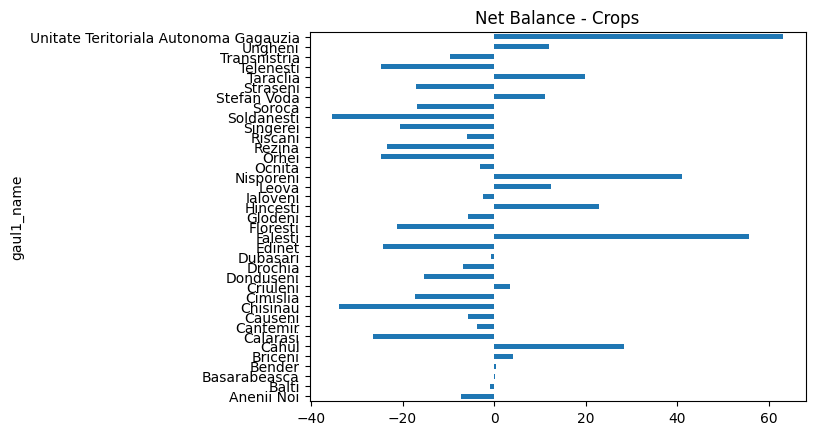

In [74]:
net_balance.set_index('gaul1_name')['net_balance'].plot.barh(
    title='Net Balance - Crops'
)

## Google Dynamic World

Dynamic World LULC is a near realtime 10m resolution global land use land cover dataset, produced using deep learning and sentinel-2 High-frequency imagery. It is freely available and openly licensed.
- [Dynamic World Website](https://www.dynamicworld.app/)
- [Dynamic World datasets on Earth Engine](https://developers.google.com/earth-engine/datasets/catalog/GOOGLE_DYNAMICWORLD_V1)

> Pasquarella, V. et al. "Dynamic World: Near real-time global 10 m land use land cover mapping." Nature Scientific Data (2022). https://www.nature.com/articles/s41597-022-01307-4

### Crop Areas

In [75]:
# Load GAUL 2024 L1 and filter by country name
country_l1 = (ee.FeatureCollection("projects/sat-io/open-datasets/FAO/GAUL/GAUL_2024_L1")
              .filter(ee.Filter.eq('gaul0_name', country_name)))

# Define the time range
start_date = ee.Date('2018-01-01')
end_date = ee.Date('2018-12-31')


# Load the Dynamic World dataset
dw = ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1") \
    .filterDate(start_date, end_date) \
    .filterBounds(country_l1) \
    .select('label')

# Identify most recurring class per pixel over the time range
dwComposite = dw.reduce(ee.Reducer.mode());

# Create a mask for crop pixels and reduce the collection
crop_class = 4
dw_cropmask_2018 = dwComposite.eq(crop_class).clip(country_l1).selfMask()

In [76]:
# Add the crop mask to the map
Map = geemap.Map()
Map.centerObject(country_l1, 7);
Map.addLayer(dw_cropmask_2018, {'palette': ['#e49635']}, "Crop Areas")
Map

Map(center=[47.19462018092226, 28.473955181059008], controls=(WidgetControl(options=['position', 'transparent_…

### 🌿 Compute Normalized Difference Vegetation Index (NDVI) of Crop Areas

The **Normalized Difference Vegetation Index (NDVI)** is one of the most widely used spectral indicators for assessing vegetation health and density from remote sensing imagery.

It is based on the principle that **healthy vegetation** strongly **absorbs visible red light (RED)** for photosynthesis while **reflecting near-infrared light (NIR)** due to internal leaf structure. NDVI quantifies this contrast:

NDVI = (NIR - RED)/(NIR + RED)

### 📈 Interpretation

**It measures vegetation greenness, which correlates with crop vigor, biomass, and potential yield.**

<img src="https://xrtechgroup.com/wp-content/uploads/2025/05/ndvi-plant-stages.png"
     width="80%" height="40%"
     style="display: block; margin-left: auto; margin-right: auto;">

*Source: https://xrtechgroup.com/what-is-ndvi-and-how-to-calculate-ndvi/*


### 🛰️ Data Sources
NDVI can be derived from many multispectral sensors — for example:
- **Sentinel-2 (ESA)** using bands *B8 (NIR)* and *B4 (RED)*
- **Landsat-8/9 (USGS/NASA)** using bands *B5 (NIR)* and *B4 (RED)*

### 🌾 Application
In agricultural monitoring, NDVI is commonly used to:
- Estimate **crop vigor and biomass**
- Identify **drought stress or pest damage**
- Track **seasonal vegetation dynamics**
- Support **yield forecasting** and **cropland mapping**


In [77]:
def mask_s2_clouds(image):
  """Masks clouds in a Sentinel-2 image using the QA band.

  Args:
      image (ee.Image): A Sentinel-2 image.

  Returns:
      ee.Image: A cloud-masked Sentinel-2 image.
  """
  qa = image.select('QA60')

  # Bits 10 and 11 are clouds and cirrus, respectively.
  cloud_bit_mask = 1 << 10
  cirrus_bit_mask = 1 << 11

  # Both flags should be set to zero, indicating clear conditions.
  mask = (
      qa.bitwiseAnd(cloud_bit_mask)
      .eq(0)
      .And(qa.bitwiseAnd(cirrus_bit_mask).eq(0))
  )

  return image.updateMask(mask).divide(10000)

# Define a function to calculate NDVI
def calculate_ndvi(image):
    ndvi = image.normalizedDifference(["B8", "B4"]).rename("NDVI")
    return image.addBands(ndvi)


def create_composite_ndvi(start, end, roi, crop_mask, cloudy_pixel_pct=20):

    # Load the Sentinel-2 images. Apply image filter (keep only images with <= 20% cloud coverage) and apply pixel-level cloud mask
    s2 = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
      .filterDate(start, end) \
      .filterBounds(roi) \
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', cloudy_pixel_pct)) \
      .map(mask_s2_clouds)


    # Map the NDVI calculation over the collection
    s2_with_ndvi = s2.map(calculate_ndvi)

    # Compute Avg NDVI between the given start and end date
    s2_with_crop_ndvi = s2_with_ndvi.select("NDVI").mean()
    # Clip to the region of interest and mask out non crop pixels
    s2_with_crop_ndvi = s2_with_crop_ndvi.clip(roi).updateMask(crop_mask)

    return s2_with_crop_ndvi

In [78]:
# Load GAUL 2024 L1 and filter by country name
country_l1 = (ee.FeatureCollection("projects/sat-io/open-datasets/FAO/GAUL/GAUL_2024_L1")
              .filter(ee.Filter.eq('gaul0_name', country_name)))

# Define the start and end dates for the time series
freq = "month"
# Calculate the number of months between the start and end dates
# Define the time range
start_date = ee.Date('2018-01-01')  # Adjust as needed
end_date = ee.Date('2025-09-30')  # Adjust as needed

# Calculate the number of months between the start and end dates
date_range = ee.List.sequence(0, end_date.difference(start_date, freq).floor())
date_range


In [79]:
# Monthly Temporal Aggregation by pixel
date_range_size = date_range.size().getInfo()
images = []
dates = []
for idx in range(date_range_size):
  offset = date_range.get(idx).getInfo()
  start = start_date.advance(offset, freq)
  end = start.advance(1, freq)

  # Print the month for reference
  print(f"Processing date: {start.format('YYYY-MM-dd').getInfo()}")

  # Compute NDVI for crop pixels
  monthly_crop_ndvi_composite = create_composite_ndvi(start=start,
                                                      end=end,
                                                      roi=country_l1,
                                                      crop_mask=dw_cropmask_2018, # we keep the crop mask fixed in time to observe change
)
  images.append(monthly_crop_ndvi_composite)
  dates.append('crops_ndvi_'+start.format('YYYY-MM-dd').getInfo())

Processing date: 2018-01-01
Processing date: 2018-02-01
Processing date: 2018-03-01
Processing date: 2018-04-01
Processing date: 2018-05-01
Processing date: 2018-06-01
Processing date: 2018-07-01
Processing date: 2018-08-01
Processing date: 2018-09-01
Processing date: 2018-10-01
Processing date: 2018-11-01
Processing date: 2018-12-01
Processing date: 2019-01-01
Processing date: 2019-02-01
Processing date: 2019-03-01
Processing date: 2019-04-01
Processing date: 2019-05-01
Processing date: 2019-06-01
Processing date: 2019-07-01
Processing date: 2019-08-01
Processing date: 2019-09-01
Processing date: 2019-10-01
Processing date: 2019-11-01
Processing date: 2019-12-01
Processing date: 2020-01-01
Processing date: 2020-02-01
Processing date: 2020-03-01
Processing date: 2020-04-01
Processing date: 2020-05-01
Processing date: 2020-06-01
Processing date: 2020-07-01
Processing date: 2020-08-01
Processing date: 2020-09-01
Processing date: 2020-10-01
Processing date: 2020-11-01
Processing date: 202

In [80]:
collection = ee.ImageCollection.fromImages(images)
collection = collection.toBands().rename(dates)

In [81]:
# Zonal statistics by region - Spatial Aggregation
geemap.zonal_stats(
    collection,                  # Raster layer
    country_l1,                   # Vector features (L1 regions)
    os.path.join(data_path, 'dynamic_world_monthly_NDVI.csv'),           # Output filepath
    statistics_type='MEAN',        # avg of pixels
    scale=1000,                   # Spatial resolution
    verbose=True,
)

Computing statistics ...
Generating URL ...
Please wait ...
Data downloaded to /content/drive/MyDrive/STI_2026/Day 2 - Satellite Data Fundamentals/Cropland Statistics/data/dynamic_world_monthly_NDVI.csv


### Convert to a dataframe for easier analysis

In [ ]:
# convert to a dataframe for easier analysis
df_dw = geemap.csv_to_df(os.path.join(data_path, 'dynamic_world_monthly_NDVI.csv'))
df_dw.head()

,crops_ndvi_2018-01-01,crops_ndvi_2018-02-01,crops_ndvi_2018-03-01,crops_ndvi_2018-04-01,crops_ndvi_2018-05-01,crops_ndvi_2018-06-01,crops_ndvi_2018-07-01,crops_ndvi_2018-08-01,crops_ndvi_2018-09-01,crops_ndvi_2018-10-01,...,crops_ndvi_2025-09-01,gaul0_name,continent,iso3_code,disp_en,map_code,gaul1_code,gaul0_code,gaul1_name,system:index
0,0.098015,NaN,-0.010444,0.401272,0.540850,0.548805,0.531142,0.487711,0.405563,0.344116,...,0.291733,Republic of Moldova,Europe,MDA,"Anenii Noi, Republic of Moldova",MDA,3737,326,Anenii Noi,000100000000000001d3
1,-0.013534,NaN,-0.018639,0.456557,0.520291,0.458192,NaN,0.562937,0.449358,0.349236,...,0.411989,Republic of Moldova,Europe,MDA,"Balti, Republic of Moldova",MDA,3738,326,Balti,000100000000000001d4
2,0.221314,NaN,-0.004220,0.377646,0.534113,0.550527,0.489326,0.420968,0.363783,0.313191,...,0.241564,Republic of Moldova,Europe,MDA,"Basarabeasca, Republic of Moldova",MDA,3739,326,Basarabeasca,000100000000000001d5
3,0.153359,NaN,-0.005640,0.393725,0.566987,0.571001,0.510616,0.429267,0.434975,0.381880,...,0.271263,Republic of Moldova,Europe,MDA,"Bender, Republic of Moldova",MDA,3740,326,Bender,000100000000000001d6
4,0.113609,NaN,-0.022058,0.360660,0.524611,0.582662,0.667071,0.659532,0.427143,0.375141,...,0.574024,Republic of Moldova,Europe,MDA,"Briceni, Republic of Moldova",MDA,3741,326,Briceni,000100000000000001d7


### Vizualize the Timeseries


In [ ]:
# Select the relevant columns (states and crop sums)
columns_of_interest = ['gaul1_name'] + [col for col in df_dw.columns if col.startswith('crops_ndvi_')]

# Create a new DataFrame with these columns
df_filtered = df_dw[columns_of_interest]

# Rename the columns to remove 'crops_ndvi_' and have only the dates
df_filtered = df_filtered.rename(columns=lambda x: x.replace('crops_ndvi_', ''))

# Set the 'gaul1_name' column as the index
df_filtered.set_index('gaul1_name', inplace=True)

# Fillna values: forward fill
cleandw_df = df_filtered.ffill(axis=1)

cleandw_df

,2018-01-01,2018-02-01,2018-03-01,2018-04-01,2018-05-01,2018-06-01,2018-07-01,2018-08-01,2018-09-01,2018-10-01,...,2024-12-01,2025-01-01,2025-02-01,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01
gaul1_name,,,,,,,,,,,,,,,,,,,,,
Anenii Noi,0.098015,0.098015,-0.010444,0.401272,0.540850,0.548805,0.531142,0.487711,0.405563,0.344116,...,0.477010,0.414178,0.305315,0.331047,0.503917,0.510168,0.570840,0.421497,0.346160,0.291733
Balti,-0.013534,-0.013534,-0.018639,0.456557,0.520291,0.458192,0.458192,0.562937,0.449358,0.349236,...,0.527741,0.416937,0.326233,0.356485,0.506287,0.506287,0.591041,0.540075,0.539337,0.411989
Basarabeasca,0.221314,0.221314,-0.004220,0.377646,0.534113,0.550527,0.489326,0.420968,0.363783,0.313191,...,0.478097,0.419258,0.342122,0.377632,0.539226,0.529731,0.537048,0.341582,0.282494,0.241564
Bender,0.153359,0.153359,-0.005640,0.393725,0.566987,0.571001,0.510616,0.429267,0.434975,0.381880,...,0.515671,0.437732,0.281191,0.363818,0.476114,0.500836,0.514537,0.351129,0.290254,0.271263
Briceni,0.113609,0.113609,-0.022058,0.360660,0.524611,0.582662,0.667071,0.659532,0.427143,0.375141,...,0.383154,0.318302,0.274663,0.288927,0.411109,0.460725,0.565010,0.627006,0.712803,0.574024
Cahul,0.199633,0.276966,0.010031,0.378041,0.510792,0.548634,0.503538,0.476615,0.349866,0.317977,...,0.398114,0.428481,0.358847,0.403559,0.541524,0.547595,0.525406,0.358734,0.304968,0.276674
Calarasi,0.006351,0.006351,0.003752,0.425485,0.583267,0.584221,0.535504,0.586028,0.555393,0.463082,...,0.543703,0.392631,0.300669,0.325896,0.479143,0.571717,0.660134,0.625788,0.636299,0.556921
Cantemir,0.182745,0.182745,0.006492,0.371139,0.514834,0.541367,0.524379,0.473706,0.391876,0.335188,...,0.487066,0.430408,0.347648,0.403685,0.558231,0.552037,0.549289,0.417163,0.356317,0.294604
Causeni,0.248477,0.248477,0.003362,0.377518,0.525950,0.563543,0.524096,0.432891,0.387918,0.340866,...,0.464822,0.401559,0.289329,0.373462,0.501311,0.524911,0.535522,0.382589,0.310918,0.260100


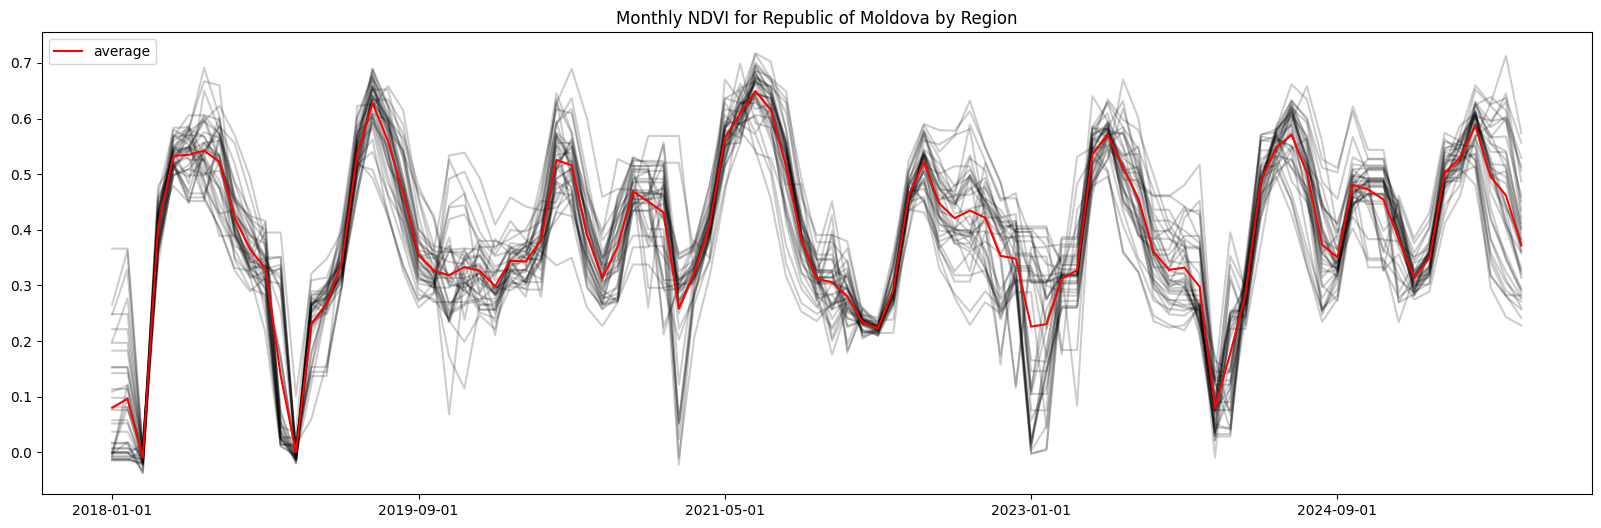

In [ ]:
# Plot the monthly NDVI for the top 10 crop districts and the average of the 10

fig, ax = plt.subplots(figsize=(20, 6))

cleandw_df.T.plot(
                   legend=False,
                   title='Monthly NDVI for '+country_name+' by Region',
                   color='black', alpha=0.2,
                   ax=ax
               )

cleandw_df.mean().plot(
                   label='average',
                   legend=True,
                   color='red',
                   ax=ax
               );